# Importing Dependencies

In [1]:
import sys, pathlib

# Walk up to the repository root (the directory containing `src/`) so this
# notebook imports the same way regardless of how deeply it is nested.
REPO_ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src").is_dir())
sys.path.append(str(REPO_ROOT))

import numpy as np
import scipy.stats as stats
import jax

from src.plotting import plot_error_sweep
from src.validation import bs_price, fd_central, fd_second
from src.validation_jax import call_price_jax, put_price_jax


# Defining Variables

$S$: Spot price

$K$: Strike price

$r$: Risk free rate

$q$: Continuous dividend yield

$\sigma$: Volatility

$T$: Time till expiration

$N(\cdot)$: Standard normal CDF

$\phi(\cdot)$: Standard normal PDF

$d_1 = \frac{\ln(S/K)+(r-q+\frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$

$d_2 = d_1 - \sigma\sqrt{T}$

In [2]:
S = 100 #spot price
K = 90 #strike price
r = 0.04 #risk free rate
q = 0.0 #continious dividend yield
sigma = 0.4 #annualized implied volatility
h_S = S * 1e-4
h_S2 = S * 1e-3
T_values = np.linspace(0.2,2,60)
eps = 1e-10

d_1 = lambda S, K, r, q, s, T: (np.log(S / K) + (r - q + (s ** 2) / 2) * T) / (s * np.sqrt(T))

def safety(x):
    return np.where(x > 0, x, 1e-9)

# $\Theta$ : Theta
#### -$\frac{\partial V} {\partial T}$ : Time decay

**Given by:**

$$\Theta_{call} = -\frac{S\sigma e^{-qT}\phi(d_1)}{2\sqrt{T}} - rKe^{-rT}N(d_2) + qSe^{-qT}N(d_1)$$

$$\Theta_{put} = -\frac{S\sigma e^{-qT}\phi(d_1)}{2\sqrt{T}} + rKe^{-rT}N(-d_2) - qSe^{-qT}N(-d_1)$$

Divided by 365 for daily decay.

In [3]:
def theta(S,K,r,q,sigma,T,daily=True):
    # making sure T ≠ 0 and sigma ≠ 0
    T_safe, sigma_safe = safety(T), safety(sigma)

    # calculating d1 and d2
    d1 = d_1(S,K,r,q,sigma_safe,T_safe)
    d2 = d1 - sigma_safe * np.sqrt(T_safe)   

    # calculating call and put
    term1 = -(S * sigma_safe * np.exp(-q * T_safe) * stats.norm.pdf(d1)) / (2 * np.sqrt(T_safe))


    call = (term1 
                    - r * K * np.exp(-r * T_safe) * stats.norm.cdf(d2) 
                    + q * S * np.exp(-q * T_safe) * stats.norm.cdf(d1))
    put = (term1 
                    + r * K * np.exp(-r * T_safe) * stats.norm.cdf(-d2) 
                    - q * S * np.exp(-q * T_safe) * stats.norm.cdf(-d1))

    # checking if T > 0 otherwise returns 0
    call = np.where(T > 0, call, 0.0)
    put = np.where(T > 0, put, 0.0)

    # returns daily if daily = True
    if daily:
        return call/365, put/365
    else:
        return call, put

In [4]:
fd_theta_call = -fd_central(lambda t: bs_price(S, K, r, q, sigma, t)[0],T_values,h_S)
fd_theta_put = -fd_central(lambda t: bs_price(S, K, r, q, sigma, t)[1],T_values,h_S)

theta_call, theta_put = theta(S,K,r,q,sigma,T_values,daily=False)

theta_call_err = np.abs(theta_call - fd_theta_call) / np.maximum(np.abs(theta_call),eps)
theta_put_err = np.abs(theta_put - fd_theta_put) / np.maximum(np.abs(theta_put),eps)

In [5]:
jax_theta_call = -jax.vmap(jax.grad(call_price_jax, argnums=5), in_axes=(None, None, None, None, None, 0))(S, K, r, q, sigma, T_values)
jax_theta_put = -jax.vmap(jax.grad(put_price_jax, argnums=5), in_axes=(None, None, None, None, None, 0))(S, K, r, q, sigma, T_values)

jax_theta_call_err = np.abs(theta_call - jax_theta_call) / np.maximum(np.abs(theta_call), eps)
jax_theta_put_err = np.abs(theta_put - jax_theta_put) / np.maximum(np.abs(theta_put), eps)

# $\Delta$ : Delta
#### $\frac{\partial V} {\partial S}$ : relationship of option price relative to underlying price

**Given by:**

$$\Delta_{call} = e^{-qT}N(d_1) \qquad \Delta_{put} = e^{-qT}(N(d_1)-1)$$

In [6]:
def delta(S,K,r,q,sigma,T):
    # making sure T ≠ 0 and sigma ≠ 0
    T_safe, sigma_safe = safety(T), safety(sigma)

    # calculating d1 and terms for call and put
    d1 = d_1(S,K,r,q,sigma_safe,T_safe)

    term1 = np.exp(-q * T_safe)
    N_d1 = stats.norm.cdf(d1)

    # calculating call and put
    call = term1 * N_d1
    put = term1 * (N_d1 - 1)

    return call, put

In [7]:
fd_delta_call = fd_central(lambda s: bs_price(s, K, r, q, sigma, T_values)[0],S,h_S)
fd_delta_put = fd_central(lambda s: bs_price(s, K, r, q, sigma, T_values)[1],S,h_S)

delta_call,delta_put = delta(S,K,r,q,sigma,T_values)

delta_call_err = np.abs(delta_call - fd_delta_call) / np.maximum(np.abs(delta_call), eps)
delta_put_err = np.abs(delta_put - fd_delta_put) / np.maximum(np.abs(delta_put), eps)

In [8]:
# jax.grad needs the differentiated argument (S) float-dtyped -- S is a plain
# int above (S = 100), which numpy/scipy upcast silently but jax.grad rejects.
jax_delta_call = jax.vmap(jax.grad(call_price_jax, argnums=0), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)
jax_delta_put = jax.vmap(jax.grad(put_price_jax, argnums=0), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)

jax_delta_call_err = np.abs(delta_call - jax_delta_call) / np.maximum(np.abs(delta_call), eps)
jax_delta_put_err = np.abs(delta_put - jax_delta_put) / np.maximum(np.abs(delta_put), eps)

# $\Gamma$ : Gamma
#### $\frac{\partial ^ 2 V} {\partial S^2}$ : ROC of $\Delta$

**Given by:**

$$\Gamma = \frac{e^{-qT}\phi(d_1)}{S\sigma\sqrt{T}}$$

Same for calls and puts.

In [9]:
def gamma(S,K,r,q,sigma,T):
    # making sure T ≠ 0, sigma ≠ 0, S ≠ 0
    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)
    
    # calculating d1
    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)

    # calculating and returning gamma 
    numerator = (np.exp(-q * T_safe) * stats.norm.pdf(d1))
    denominator = (S_safe * sigma_safe * np.sqrt(T_safe))
    gamma_val = numerator/denominator

    return  np.where(T > 0, gamma_val, 0.0) 

In [10]:
fd_gamma = fd_second(lambda s: bs_price(s, K, r, q, sigma, T_values)[0],S,h_S2)

a_gamma = gamma(S,K,r,q,sigma,T_values)

gamma_err = np.abs(a_gamma - fd_gamma) / np.maximum(np.abs(a_gamma),eps)

In [11]:
jax_gamma = jax.vmap(jax.grad(jax.grad(call_price_jax, argnums=0), argnums=0), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)

jax_gamma_err = np.abs(a_gamma - jax_gamma) / np.maximum(np.abs(a_gamma), eps)

# $\nu$ : Vega
#### $\frac{\partial V} {\partial \sigma}$ : relationship between option price and implied volatility

**Given by:**

$$\nu = Se^{-qT}\phi(d_1)\sqrt{T}$$

Divided by 100 for P&L per 1 vol point ($\Delta\sigma=0.01$). Same for calls and puts.

In [12]:
def vega(S,K,r,q,sigma,T,scaled=True):
    # making sure T ≠ 0 and sigma ≠ 0
    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)

    # calculating vega
    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)
    vega_val = S_safe * np.exp(-q * T_safe) * stats.norm.pdf(d1) * np.sqrt(T_safe)

    # scaling vega if scaling
    output = vega_val / 100 if scaled else vega_val

    return np.where((T > 0) & (sigma > 0) & (S > 0), output, 0.0)

In [13]:
fd_vega = fd_central(lambda s: bs_price(S, K, r, q, s, T_values)[0],sigma,h_S)

a_vega = vega(S,K,r,q,sigma,T_values,scaled=False)

vega_err = np.abs(a_vega - fd_vega) / np.maximum(np.abs(a_vega),eps)

In [14]:
jax_vega = jax.vmap(jax.grad(call_price_jax, argnums=4), in_axes=(None, None, None, None, None, 0))(S, K, r, q, sigma, T_values)

jax_vega_err = np.abs(a_vega - jax_vega) / np.maximum(np.abs(a_vega), eps)

# $\rho$ : Rho
#### $\frac{\partial V} {\partial r}$ : relationship between option price and the risk free rate

**Given by:**

$$\rho_{call} = KTe^{-rT}N(d_2) \qquad \rho_{put} = -KTe^{-rT}N(-d_2)$$

Divided by 100 for P&L per 1% rate move.

In [15]:
def rho(S,K,r,q,sigma,T,scaled=True):
    # making sure T ≠ 0 and sigma ≠ 0
    T_safe, sigma_safe = safety(T), safety(sigma)
    
    d2 = d_1(S,K,r,q,sigma_safe,T_safe) - sigma_safe * np.sqrt(T_safe)
    term1 = K * T_safe * np.exp(-r * T_safe)

    call = term1 * stats.norm.cdf(d2)
    put = -term1 * stats.norm.cdf(-d2)

    # scaling rho if scaling
    if scaled:
        call = call / 100
        put = put / 100

    return np.where(T > 0, call, 0.0), np.where(T > 0, put, 0.0)

In [16]:
fd_rho_call = fd_central(lambda R: bs_price(S, K, R, q, sigma, T_values)[0],r,h_S)
fd_rho_put = fd_central(lambda R: bs_price(S, K, R, q, sigma, T_values)[1],r,h_S)

rho_call, rho_put = rho(S,K,r,q,sigma,T_values,scaled=False)

rho_call_err = np.abs(rho_call - fd_rho_call) / np.maximum(np.abs(rho_call),eps)
rho_put_err = np.abs(rho_put - fd_rho_put) / np.maximum(np.abs(rho_put),eps)

In [17]:
jax_rho_call = jax.vmap(jax.grad(call_price_jax, argnums=2), in_axes=(None, None, None, None, None, 0))(S, K, r, q, sigma, T_values)
jax_rho_put = jax.vmap(jax.grad(put_price_jax, argnums=2), in_axes=(None, None, None, None, None, 0))(S, K, r, q, sigma, T_values)

jax_rho_call_err = np.abs(rho_call - jax_rho_call) / np.maximum(np.abs(rho_call), eps)
jax_rho_put_err = np.abs(rho_put - jax_rho_put) / np.maximum(np.abs(rho_put), eps)

# Vanna
#### $\frac{\partial ^ 2 V} {\partial S \partial \sigma}$

**Given by:**

$$\text{Vanna} = -e^{-qT}\phi(d_1)\frac{d_2}{\sigma}$$

Divided by 100. Same for calls and puts.

In [18]:
def vanna(S,K,r,q,sigma,T,scaled=True):
    # controlling for edge cases
    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)

    # calculating vanna
    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)
    d2 = d1 - sigma_safe * np.sqrt(T_safe)  

    vanna_val = -np.exp(-q * T_safe) * stats.norm.pdf(d1) * d2 / sigma_safe

    # scaling vanna if scaling = True
    output = vanna_val / 100 if scaled else vanna_val

    return np.where((T > 0) & (sigma > 0) & (S > 0), output, 0.0)

In [19]:
jax_vanna = jax.vmap(jax.grad(jax.grad(call_price_jax, argnums=0), argnums=4), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)

a_vanna = vanna(S,K,r,q,sigma,T_values,scaled=False)

jax_vanna_err = np.abs(a_vanna - jax_vanna) / np.maximum(np.abs(a_vanna), eps)

# Volga
#### $\frac{\partial ^ 2 V} {\partial \sigma^2}$

**Given by:**

$$\text{Volga} = \nu \cdot \frac{d_1 d_2}{\sigma}$$

($\nu$ unscaled.) Divided by 10,000.

In [20]:
def volga(S,K,r,q,sigma,T,scaled=True):
    # controlling for edge cases
    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)

    # calculating volga
    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)
    d2 = d1 - sigma_safe * np.sqrt(T_safe)  

    vega = S_safe * np.exp(-q * T_safe) * stats.norm.pdf(d1) * np.sqrt(T_safe)
    volga_val = vega * d1 * d2 / sigma_safe

    # scaling volga if scaling = True
    output = volga_val / 10_000 if scaled else volga_val

    return np.where((T > 0) & (sigma > 0) & (S > 0), output, 0.0)

In [21]:
fd_volga = fd_second(lambda s: bs_price(S, K, r, q, s, T_values)[0],sigma,h_S2)

a_volga = volga(S,K,r,q,sigma,T_values,scaled=False)

volga_err = np.abs(a_volga - fd_volga) / np.maximum(np.abs(a_volga),eps)

In [22]:
jax_volga = jax.vmap(jax.grad(jax.grad(call_price_jax, argnums=4), argnums=4), in_axes=(None, None, None, None, None, 0))(S, K, r, q, sigma, T_values)

jax_volga_err = np.abs(a_volga - jax_volga) / np.maximum(np.abs(a_volga), eps)

# Charm
#### $\frac{\partial ^ 2 V} {\partial S \partial T}$

**Given by:**

Letting $X = e^{-qT}\phi(d_1)\left(\frac{r-q}{\sigma\sqrt{T}} - \frac{d_2}{2T}\right)$,

$$\text{Charm}_{call} = qe^{-qT}N(d_1) - X \qquad \text{Charm}_{put} = -qe^{-qT}N(-d_1) - X$$

Divided by 365.

In [23]:
def charm(S,K,r,q,sigma,T,scaled=True):
    # controlling for edge cases
    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)

    # calculating charm
    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)
    d2 = d1 - sigma_safe * np.sqrt(T_safe)

    term2 = np.exp(-q * T_safe) * stats.norm.pdf(d1) * (((r - q) / (sigma_safe * np.sqrt(T_safe))) - (d2 / (2 * T_safe)))

    call = q * np.exp(-q * T_safe) * stats.norm.cdf(d1) - term2
    put = -q * np.exp(-q * T_safe) * stats.norm.cdf(-d1) - term2

    call = np.where((T > 0) & (sigma > 0) & (S > 0), call, 0.0)
    put = np.where((T > 0) & (sigma > 0) & (S > 0), put, 0.0)
    
    # scaling charm if scaling = True
    if scaled:
        return call / 365, put / 365
    
    return call, put

In [24]:
jax_charm_call = -jax.vmap(jax.grad(jax.grad(call_price_jax, argnums=0), argnums=5), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)
jax_charm_put = -jax.vmap(jax.grad(jax.grad(put_price_jax, argnums=0), argnums=5), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)


charm_call,charm_put = charm(S,K,r,q,sigma,T_values,scaled=False)

jax_charm_call_err = np.abs(charm_call - jax_charm_call) / np.maximum(np.abs(charm_call), eps)
jax_charm_put_err = np.abs(charm_put - jax_charm_put) / np.maximum(np.abs(charm_put), eps)

# Speed
#### $\frac{\partial ^ 3 V} {\partial S^3}$

**Given by:**

$$\text{Speed} = -\frac{e^{-qT}\phi(d_1)}{S^2\sigma\sqrt{T}}\left(\frac{d_1}{\sigma\sqrt{T}}+1\right)$$

Same for calls and puts.

In [25]:
def speed(S,K,r,q,sigma,T):
    # controlling for edge cases
    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)
    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)
    output = -(np.exp(-q * T_safe) * stats.norm.pdf(d1) / (S_safe ** 2 * sigma_safe * np.sqrt(T_safe))) * (d1 / (sigma_safe * np.sqrt(T_safe)) + 1)
    return np.where((T > 0) & (sigma > 0) & (S > 0), output, 0.0)

In [26]:
jax_speed = jax.vmap(jax.grad(jax.grad(jax.grad(call_price_jax, argnums=0), argnums=0), argnums=0), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)

a_speed = speed(S,K,r,q,sigma,T_values)

jax_speed_err = np.abs(a_speed - jax_speed) / np.maximum(np.abs(a_speed), eps)

# Zomma
#### $\frac{\partial ^ 3 V} {\partial S^2 \partial \sigma}$

**Given by:**

$$\text{Zomma} = \Gamma\cdot\frac{d_1 d_2 - 1}{\sigma}$$

($\Gamma$ unscaled.) Divided by 100.

In [27]:
def zomma(S,K,r,q,sigma,T,scaled=True):

    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)

    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)
    d2 = d1 - sigma_safe * np.sqrt(T_safe)

    numerator = (np.exp(-q * T_safe) * stats.norm.pdf(d1))
    denominator = (S_safe * sigma_safe * np.sqrt(T_safe))
    gamma_val = numerator/denominator

    output = gamma_val * (d1 * d2 - 1) / sigma_safe
    output = output / 100 if scaled else output

    return np.where((T > 0) & (sigma > 0) & (S > 0), output, 0.0)

In [28]:
jax_zomma = jax.vmap(jax.grad(jax.grad(jax.grad(call_price_jax, argnums=0), argnums=0), argnums=4), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)

a_zomma = zomma(S,K,r,q,sigma,T_values,scaled=False)

jax_zomma_err = np.abs(a_zomma - jax_zomma) / np.maximum(np.abs(a_zomma), eps)

# Color
#### $\frac{\partial ^ 3 V} {\partial S^2 \partial T}$

**Given by:**

$$\text{Color} = \Gamma\left[q + \frac{d_1(r-q)}{\sigma\sqrt{T}} + \frac{1-d_1 d_2}{2T}\right]$$

Divided by 365.

In [29]:
def color(S,K,r,q,sigma,T,scaled=True):
    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)
    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)
    d2 = d1 - sigma_safe * np.sqrt(T_safe)

    numerator = np.exp(-q * T_safe) * stats.norm.pdf(d1)
    denominator = S_safe * sigma_safe * np.sqrt(T_safe)
    gamma_val = numerator / denominator

    bracket = q + d1 * (r - q) / (sigma_safe * np.sqrt(T_safe)) + (1 - d1 * d2) / (2 * T_safe)
    output = gamma_val * bracket

    if scaled:
        output /= 365
    return np.where((T > 0) & (sigma > 0) & (S > 0), output, 0.0)

In [30]:
jax_color = -jax.vmap(jax.grad(jax.grad(jax.grad(call_price_jax, argnums=0), argnums=0), argnums=5), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)

a_color = color(S,K,r,q,sigma,T_values,scaled=False)

jax_color_err = np.abs(a_color - jax_color) / np.maximum(np.abs(a_color), eps)

# Ultima
#### $\frac{\partial ^ 3 V} {\partial \sigma^3}$

**Given by:**

$$\text{Ultima} = \frac{\nu}{\sigma^2}\left[d_1 d_2(d_1 d_2 - 1) - (d_1^2+d_2^2)\right]$$

($\nu$ unscaled.) Divided by 1,000,000.

In [31]:
def ultima(S,K,r,q,sigma,T,scaled=True):
    T_safe, sigma_safe, S_safe = safety(T), safety(sigma), safety(S)

    d1 = d_1(S_safe,K,r,q,sigma_safe,T_safe)
    d2 = d1 - sigma_safe * np.sqrt(T_safe)

    output = vega(S,K,r,q,sigma,T,scaled=False) / (sigma_safe ** 2) * (d1 * d2 * (d1 * d2 - 1) - (d1 ** 2 + d2 ** 2))

    if scaled:
        output /= 1_000_000

    return np.where((T > 0) & (sigma > 0) & (S > 0), output, 0.0)

In [32]:
jax_ultima = jax.vmap(jax.grad(jax.grad(jax.grad(call_price_jax, argnums=4), argnums=4), argnums=4), in_axes=(None, None, None, None, None, 0))(float(S), K, r, q, sigma, T_values)

a_ultima = ultima(S,K,r,q,sigma,T_values,scaled=False)

jax_ultima_err = np.abs(a_ultima - jax_ultima) / np.maximum(np.abs(a_ultima), eps)

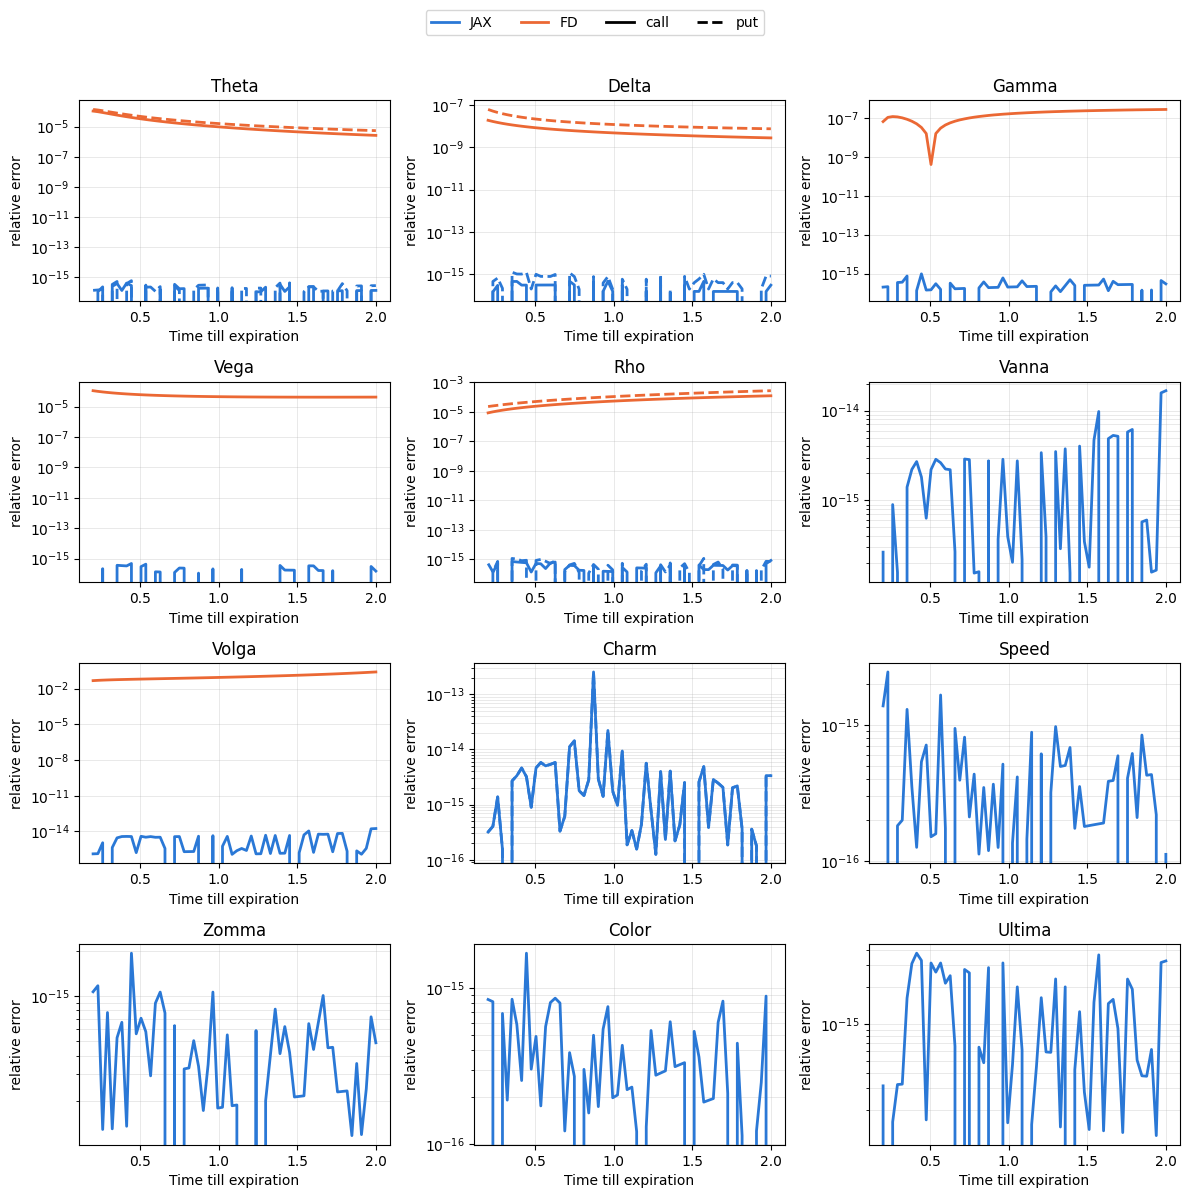

In [33]:
results = {"Theta":{"JAX":(jax_theta_call_err,jax_theta_put_err),"FD":(theta_call_err,theta_put_err)}, 
           "Delta":{"JAX":(jax_delta_call_err,jax_delta_put_err),"FD":(delta_call_err,delta_put_err)},
           "Gamma":{"JAX":jax_gamma_err,"FD":gamma_err},
           "Vega":{"JAX":jax_vega_err,"FD":vega_err},
           "Rho":{"JAX":(jax_rho_call_err,jax_rho_put_err),"FD":(rho_call_err,rho_put_err)},
           "Vanna":{"JAX":jax_vanna_err},
           "Volga":{"JAX":jax_volga_err,"FD":volga_err},
           "Charm":{"JAX":(jax_charm_call_err,jax_charm_put_err)},
           "Speed":{"JAX":jax_speed_err},
           "Zomma":{"JAX":jax_zomma_err},
           "Color":{"JAX":jax_color_err},
           "Ultima":{"JAX":jax_ultima_err}
           }

x = T_values
x_label = "Time till expiration"

fig, axes = plot_error_sweep(x, x_label, results, ncols=3, axis_size=(4, 3))

# Importing Dependencies

# Greek Validation

### Why Validate the Greeks?

**The problem being solved:**

A closed-form Greek is only useful if it is verifiably correct. When implementing closed-form Greek formulas, it is easy to make subtle mistakes. A missed term, sign flip, or scaling factor applied under the wrong convention can still return somewhat plausible numbers. These mistakes are sometimes hard to catch and might not announce themselves on a graph, so checking a formula by eye is not enough on its own. Introducing an independent numerical ground truth makes catching subtle errors easier, ultimately confirming accuracy.

**Why it matters in the real world:**

While in this notebook Greeks are modeled as descriptive statistics, at an actual trading desk they are the inputs used to size hedges. Due to this, a wrong Delta or Vega is not a cosmetic error. It can lead to real losses that were easily avoidable. This is why validating Greeks is a required step. The cost of an error is not just a wrong number, it is a genuine risk factor.

**Why use two independent methods:**

Relying on a single validation method carries its own risk, since a method can have the same blind spot as the implementation it is checking. This is the main reason behind validating with finite differences as well as automatic differentiation. Two independently derived methods agreeing with an analytic formula is much stronger evidence of correctness than just one agreeing in isolation.

### Methodology

##### Finite-difference (FD) method:

**Math and error:**

First derivative given by, $$f'(x) \approx \frac{[f(x+h) - f(x - h)]}{2h}$$
Second derivative given by, $$f'(x) \approx \frac{[f(x+h)-2f(x)+f(x-h)]}{h^2}$$
The first and second derivative approximation have truncation error of $O(h^2)$, but the second derivative approximation is more exposed to floating point errors.

**The step size sweet spot:**

Step size calibration plays a substantial role in error calculation. If the step size is too large, truncation error becomes an issue. If the step size is too small, precision decays as near equal term almost completely cancel each other out. During calibration there is a sweet spot for the step size. This sweet spot shrinks as the derivative order increases. Due to this fact, the higher the derivative being approximated the more error is introduced.

##### JAX:

**Overview and error:**

Adjoint algorithmic differentiation (AAD) is the process that JAX uses under the hood. This process is more efficient and accurate than FD. The error when using AAD for a first order derivative has no truncation and step size error only containing floating point rounding errors. Due to this JAX's AAD error sits around $1e^{-13}$ to $1e^{-16}$ for all greeks. Substantially tighter than the FD error.

A key thing to note with JAX is that floats are defaulted to 32-bit. Adjusting to 64-bit improves the floating point accuracy, but has to be explicit in the config ```jax.config.update("jax_enable_x64", True)```. If the config is not run before JAX is used then 32-bit precision is used.

### Further Reading

Giles, M. and Glasserman, P. (2006). "Smoking Adjoints: Fast Monte Carlo Greeks." *Risk*, January 2006, pp. 92–96. The paper credited with popularising adjoint algorithmic differentiation in derivatives risk management.

Homescu, C. (2011). "Adjoints and Automatic (Algorithmic) Differentiation in Computational Finance." [arXiv:1107.1831](https://arxiv.org/abs/1107.1831). A broader technical survey of AAD applied to Greeks and calibration.